# Per-strain consensus sequences (20260630 pairwise interaction run)

Build a consensus 16S sequence for each strain tested, using the demultiplexed reads.

**Idea.** Each strain is assigned to many wells, each time paired with a *different* partner
(see `setup/strain_layout_20260630.csv`; `strain1`/`strain2` = the two strains in a well).
Within one well the reads are usually dominated by one of the two strains, so a single well is
not reliable. But because a given strain recurs across ~all of its wells while its partners change,
**the sequence that shows up in a majority of that strain's wells is the strain itself.**

**Method.**
1. *Per well* — cluster the reads by identity (greedy, `WITHIN_THR`), keep each cluster with
   `>= MIN_READS` reads and represent it by the cluster **medoid**. A well thus yields 1–2
   representative sequences (its dominant strain(s)).
2. *Per strain* — pool the representatives from every well the strain appears in, cluster them
   across wells (`CROSS_THR`), and pick the cross-cluster that spans the **most distinct wells**.
   If that cluster covers a majority of the strain's *informative* wells (wells that produced any
   reads), it is the strain.
3. *Consensus* — merge that cluster's per-well representatives by **majority vote** at each aligned
   position (reference-anchored, with majority-supported insertions).

Note: ~63% of wells are empty, so coverage is reported against *informative* wells (wells with reads),
which is the meaningful denominator for "a majority of the samples where the strain was present".


In [1]:
import os, glob, time, collections
import numpy as np, pandas as pd
import edlib
from Bio import SeqIO

# ---- paths ----
BASE      = '/home/rl/scripts/karl/pairwise_interaction_experiments/20260630'
LAYOUT    = f'{BASE}/setup/strain_layout_20260630.csv'
DEMUX_DIR = f'{BASE}/demux2/unflipped'
OUT_DIR   = f'{BASE}/analysis/consensus'
os.makedirs(OUT_DIR, exist_ok=True)

# ---- parameters ----
LEN_LO, LEN_HI = 1350, 1500   # keep reads within full-length 16S window
READ_CAP       = 80           # max reads used per well (speed)
WITHIN_THR     = 0.92         # identity to merge reads of the same strain within a well
MIN_READS      = 3            # min reads for a within-well cluster to count
CROSS_THR      = 0.92         # identity to merge per-well representatives across wells
MEDOID_CAP     = 25           # subsample size when computing a medoid


In [2]:
# ---- helpers ----
def identity(a, b):
    r = edlib.align(a, b, mode='NW', task='distance')
    return 1 - r['editDistance'] / max(len(a), len(b))

def load_reads(fq):
    if not os.path.exists(fq) or os.path.getsize(fq) == 0:
        return []
    out = []
    for rec in SeqIO.parse(fq, 'fastq'):
        s = str(rec.seq)
        if LEN_LO <= len(s) <= LEN_HI:
            out.append(s)
            if len(out) >= READ_CAP:
                break
    return out

def greedy_cluster(seqs, thr):
    """Greedy identity clustering. Returns list of [seed_seq, [member_indices]]."""
    cents = []
    for i, s in enumerate(seqs):
        best, bj = -1.0, -1
        for j, (cs, mem) in enumerate(cents):
            v = identity(s, cs)
            if v > best:
                best, bj = v, j
        if best >= thr:
            cents[bj][1].append(i)
        else:
            cents.append([s, [i]])
    return cents

def medoid(seqs):
    """Sequence minimizing total edit distance to the others (subsampled for speed)."""
    if len(seqs) == 1:
        return seqs[0]
    sub = seqs[:MEDOID_CAP]
    best, best_tot = sub[0], None
    for a in sub:
        tot = sum(edlib.align(a, b, mode='NW', task='distance')['editDistance'] for b in sub)
        if best_tot is None or tot < best_tot:
            best_tot, best = tot, a
    return best

def well_representatives(fq):
    """Per-well: cluster reads, return medoid of each cluster with >= MIN_READS reads."""
    reads = load_reads(fq)
    if not reads:
        return []
    reps = []
    for seed, mem in greedy_cluster(reads, WITHIN_THR):
        if len(mem) >= MIN_READS:
            reps.append(medoid([reads[i] for i in mem]))
    return reps

def majority_consensus(members):
    """Majority-vote consensus of sequences, anchored on their medoid (handles indels)."""
    if len(members) == 1:
        return members[0]
    ref = medoid(members)
    col = collections.defaultdict(collections.Counter)   # ref position -> base counts (incl '-')
    ins = collections.defaultdict(list)                  # ref position -> inserted strings
    for m in members:
        r  = edlib.align(m, ref, mode='NW', task='path')
        na = edlib.getNiceAlignment(r, m, ref)
        q, t = na['query_aligned'], na['target_aligned']
        rp, cur = -1, []
        for qc, tc in zip(q, t):
            if tc != '-':                 # a reference position
                if cur:
                    ins[rp].append(''.join(cur)); cur = []
                rp += 1
                col[rp][qc] += 1
            else:                         # insertion relative to reference
                cur.append(qc)
        if cur:
            ins[rp].append(''.join(cur))
    N = len(members)
    out = []
    for p in range(max(col) + 1):
        base, _ = col[p].most_common(1)[0]
        if base != '-':                   # majority says keep this position
            out.append(base)
        seg = ins.get(p, [])              # insertion after position p, if majority-supported
        if len(seg) > N / 2:
            out.append(collections.Counter(seg).most_common(1)[0][0])
    return ''.join(out)


In [3]:
# ---- load layout, map strains -> wells, and each well -> fastq ----
df = pd.read_csv(LAYOUT)
df['fq'] = df.apply(lambda r: f"{DEMUX_DIR}/Plate{int(r['dest_plate']):02d}_{r['dest_well']}.fastq", axis=1)

strain_wells = collections.defaultdict(list)   # strain -> [fastq paths]
for _, r in df.iterrows():
    for c in ('strain1', 'strain2'):
        s = r[c]
        if isinstance(s, str) and s:
            strain_wells[s].append(r['fq'])

strains = sorted(strain_wells)
sizes = df['fq'].apply(lambda f: os.path.getsize(f) if os.path.exists(f) else -1)
print(f"wells (layout rows)       : {len(df)}")
print(f"  missing files           : {(sizes < 0).sum()}")
print(f"  empty (0 byte) files    : {(sizes == 0).sum()}")
print(f"  non-empty files         : {(sizes > 0).sum()}")
print(f"unique strains            : {len(strains)}")
wc = pd.Series({s: len(w) for s, w in strain_wells.items()})
print(f"wells per strain (min/median/max): {wc.min()} / {int(wc.median())} / {wc.max()}")


wells (layout rows)       : 9120
  missing files           : 0
  empty (0 byte) files    : 5718
  non-empty files         : 3402
unique strains            : 100
wells per strain (min/median/max): 4 / 201 / 212


In [4]:
# ---- Phase A: per-well representatives (each unique well processed once, then reused) ----
all_wells = sorted(set(df['fq']))
well_reps = {}
t0 = time.time()
for i, fq in enumerate(all_wells):
    well_reps[fq] = well_representatives(fq)
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{len(all_wells)} wells processed ({time.time()-t0:.0f}s)")
n_inf = sum(1 for v in well_reps.values() if v)
print(f"done: {len(all_wells)} wells, {n_inf} informative (>=1 representative), {time.time()-t0:.0f}s")


  1000/9120 wells processed (13s)


  2000/9120 wells processed (21s)


  3000/9120 wells processed (30s)


  4000/9120 wells processed (39s)


  5000/9120 wells processed (46s)


  6000/9120 wells processed (55s)
  7000/9120 wells processed (56s)
  8000/9120 wells processed (56s)
  9000/9120 wells processed (56s)
done: 9120 wells, 2846 informative (>=1 representative), 56s


In [5]:
# ---- Phase B: per-strain cross-well consensus ----
rows, consensus_seqs = [], {}
t0 = time.time()
for s in strains:
    wells = strain_wells[s]
    reps = []                                   # (rep_seq, well_index)
    informative = 0
    for wi, fq in enumerate(wells):
        wr = well_reps[fq]
        if wr:
            informative += 1
        for seq in wr:
            reps.append((seq, wi))

    # cluster the per-well representatives across wells
    cc = []
    for seq, wi in reps:
        best, bj = -1.0, -1
        for j, c in enumerate(cc):
            v = identity(seq, c['seed'])
            if v > best:
                best, bj = v, j
        if best >= CROSS_THR:
            cc[bj]['mem'].append((seq, wi))
        else:
            cc.append({'seed': seq, 'mem': [(seq, wi)]})
    for c in cc:
        c['nwells'] = len(set(wi for _, wi in c['mem']))
    cc.sort(key=lambda c: -c['nwells'])

    top_wells = cc[0]['nwells'] if cc else 0
    second    = cc[1]['nwells'] if len(cc) > 1 else 0
    cov = top_wells / informative if informative else 0.0
    is_majority = informative > 0 and top_wells > informative / 2

    cons = ''
    if cc and cc[0]['mem']:
        cons = majority_consensus([m for m, _ in cc[0]['mem']])
        consensus_seqs[s] = cons

    if not informative:
        status = 'no_data'
    elif is_majority:
        status = 'ok' if informative >= 2 else 'ok_single_well'
    else:
        status = 'no_majority'

    rows.append(dict(strain=s, assigned_wells=len(wells), informative_wells=informative,
                     top_cluster_wells=top_wells, coverage=round(cov, 3),
                     second_cluster_wells=second, n_cross_clusters=len(cc),
                     top_cluster_members=len(cc[0]['mem']) if cc else 0,
                     consensus_len=len(cons), status=status))

summary = pd.DataFrame(rows).sort_values('informative_wells', ascending=False).reset_index(drop=True)
print(f"phase B done in {time.time()-t0:.0f}s")
print(summary['status'].value_counts())
summary.head(15)


phase B done in 7s
status
ok                90
no_majority        9
ok_single_well     1
Name: count, dtype: int64


,strain,assigned_wells,informative_wells,top_cluster_wells,coverage,second_cluster_wells,n_cross_clusters,top_cluster_members,consensus_len,status
0,E2,203,79,79,1.000,13,10,81,1422,ok
1,E10,199,77,77,1.000,8,6,81,1422,ok
2,F17,195,77,76,0.987,7,9,79,1422,ok
3,H19,202,77,77,1.000,11,8,82,1421,ok
4,I11,192,74,74,1.000,10,9,79,1422,ok
5,M21,204,74,53,0.716,37,16,54,1427,ok
6,G17,196,74,74,1.000,28,7,82,1419,ok
7,I3,203,73,33,0.452,31,15,33,1422,no_majority
8,G21,205,71,48,0.676,25,12,48,1434,ok
9,G5,205,71,71,1.000,9,7,72,1422,ok


In [6]:
# ---- write outputs: consensus FASTA + summary CSV ----
fasta_path = f'{OUT_DIR}/strain_consensus_20260630.fasta'
csv_path   = f'{OUT_DIR}/strain_consensus_summary_20260630.csv'

with open(fasta_path, 'w') as fh:
    for _, row in summary.iterrows():
        s = row['strain']
        if s in consensus_seqs and row['status'] in ('ok', 'ok_single_well'):
            fh.write(f">{s} informative_wells={row['informative_wells']} "
                     f"support={row['top_cluster_wells']}/{row['informative_wells']} "
                     f"coverage={row['coverage']} status={row['status']}\n")
            fh.write(consensus_seqs[s] + '\n')

summary.to_csv(csv_path, index=False)
n_written = summary['status'].isin(['ok', 'ok_single_well']).sum()
print(f"wrote {n_written} consensus sequences -> {fasta_path}")
print(f"wrote summary ({len(summary)} strains)     -> {csv_path}")
summary


wrote 91 consensus sequences -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus/strain_consensus_20260630.fasta
wrote summary (100 strains)     -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus/strain_consensus_summary_20260630.csv


,strain,assigned_wells,informative_wells,top_cluster_wells,coverage,second_cluster_wells,n_cross_clusters,top_cluster_members,consensus_len,status
0,E2,203,79,79,1.000,13,10,81,1422,ok
1,E10,199,77,77,1.000,8,6,81,1422,ok
2,F17,195,77,76,0.987,7,9,79,1422,ok
3,H19,202,77,77,1.000,11,8,82,1421,ok
4,I11,192,74,74,1.000,10,9,79,1422,ok
...,...,...,...,...,...,...,...,...,...,...
95,G14,7,3,3,1.000,1,3,5,1422,ok
96,P23,7,3,3,1.000,1,4,3,1401,ok
97,G10,9,2,2,1.000,0,1,2,1422,ok
98,J11,9,2,2,1.000,0,1,2,1419,ok


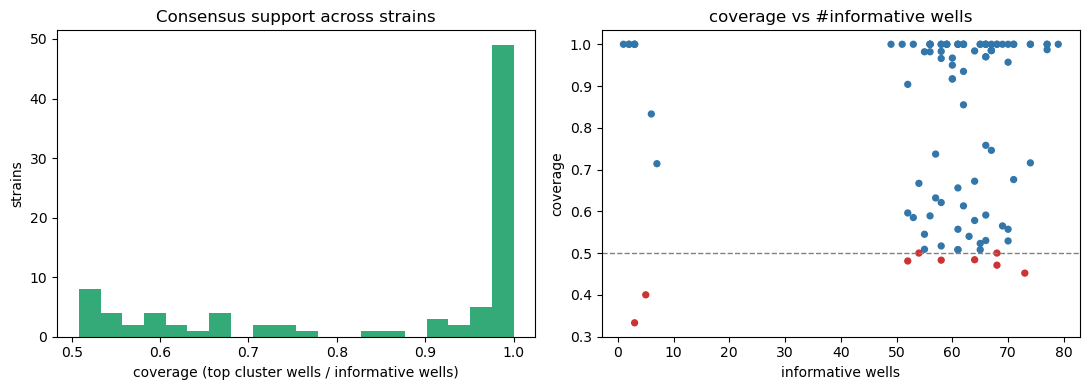

flagged strains (no clear majority / no data):


,strain,assigned_wells,informative_wells,top_cluster_wells,second_cluster_wells,coverage,status
7,I3,203,73,33,31,0.452,no_majority
18,G13,203,68,34,25,0.500,no_majority
20,M9,202,68,32,28,0.471,no_majority
40,G12,207,64,31,23,0.484,no_majority
64,G18,199,58,28,13,0.483,no_majority
81,E5,203,54,27,25,0.500,no_majority
87,M13,198,52,25,20,0.481,no_majority
92,G23,11,5,2,1,0.400,no_majority
93,H7,8,3,1,1,0.333,no_majority


In [7]:
# ---- quick diagnostics ----
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ok = summary[summary['status'].isin(['ok', 'ok_single_well'])]
ax[0].hist(ok['coverage'], bins=20, color='#3a7')
ax[0].set(xlabel='coverage (top cluster wells / informative wells)', ylabel='strains',
          title='Consensus support across strains')
ax[1].scatter(summary['informative_wells'], summary['coverage'], s=18,
              c=(summary['status'] == 'no_majority').map({True: '#c33', False: '#37a'}))
ax[1].set(xlabel='informative wells', ylabel='coverage', title='coverage vs #informative wells')
ax[1].axhline(0.5, ls='--', c='grey', lw=1)
plt.tight_layout(); plt.show()

# strains needing a look
flagged = summary[summary['status'].isin(['no_majority', 'no_data'])]
print("flagged strains (no clear majority / no data):")
flagged[['strain','assigned_wells','informative_wells','top_cluster_wells','second_cluster_wells','coverage','status']]


## Distinct 16S sequence types

Full-length 16S is highly conserved, so many isolates with different labels can share an identical
sequence. Group the confident consensus sequences into **16S types** (single-linkage at
`TYPE_THR` identity) to see how many genuinely distinct sequences the 100 strains represent.

In [8]:
TYPE_THR = 0.99   # identity to call two consensus sequences the same 16S type

ok_strains = [s for s in strains if s in consensus_seqs and
              summary.set_index('strain').loc[s, 'status'] in ('ok', 'ok_single_well')]

# single-linkage grouping via union-find over >=TYPE_THR identity edges
parent = {s: s for s in ok_strains}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    parent[find(a)] = find(b)

for i in range(len(ok_strains)):
    a = ok_strains[i]
    for j in range(i + 1, len(ok_strains)):
        b = ok_strains[j]
        if identity(consensus_seqs[a], consensus_seqs[b]) >= TYPE_THR:
            union(a, b)

groups = collections.defaultdict(list)
for s in ok_strains:
    groups[find(s)].append(s)
type_list = sorted(groups.values(), key=len, reverse=True)

print(f"{len(ok_strains)} confident consensus sequences collapse into "
      f"{len(type_list)} distinct 16S types (>= {TYPE_THR} identity).\n")
type_rows = []
for k, members in enumerate(type_list, 1):
    rep = max(members, key=lambda s: summary.set_index('strain').loc[s, 'informative_wells'])
    type_rows.append(dict(type_id=f'T{k:02d}', n_strains=len(members),
                          representative=rep, strains=' '.join(sorted(members))))
    if len(members) > 1:
        print(f"  T{k:02d} ({len(members):2d} strains): {' '.join(sorted(members))}")
types_df = pd.DataFrame(type_rows)

# write one representative sequence per 16S type, and a strain->type map
with open(f'{OUT_DIR}/strain_16S_types_20260630.fasta', 'w') as fh:
    for _, row in types_df.iterrows():
        fh.write(f">{row['type_id']} rep={row['representative']} n_strains={row['n_strains']} "
                 f"strains={row['strains'].replace(' ', ',')}\n")
        fh.write(consensus_seqs[row['representative']] + '\n')

strain2type = {s: row['type_id'] for _, row in types_df.iterrows() for s in row['strains'].split()}
type_map = summary.copy()
type_map['type_16S'] = type_map['strain'].map(strain2type).fillna('')
type_map.to_csv(f'{OUT_DIR}/strain_consensus_summary_20260630.csv', index=False)
types_df.to_csv(f'{OUT_DIR}/strain_16S_types_20260630.csv', index=False)
print(f"\nwrote {len(types_df)} representative type sequences and strain->type map to {OUT_DIR}/")
types_df


91 confident consensus sequences collapse into 24 distinct 16S types (>= 0.99 identity).

  T01 (46 strains): A10 A15 A8 C20 C22 C24 D23 E10 E12 E18 E2 E20 E22 E7 E8 E9 F13 F15 F23 F5 G1 G10 G11 G14 G15 G19 G2 G20 G3 G5 G8 G9 H11 H15 H17 H19 I11 I9 J1 M11 O11 O13 O9 P11 P19 P21
  T02 ( 5 strains): F17 F7 J9 O15 P15
  T03 ( 4 strains): A1 A2 A6 F21
  T04 ( 4 strains): G17 J13 J5 O3
  T05 ( 4 strains): G22 H23 J11 O19
  T06 ( 3 strains): E13 E6 M19
  T07 ( 3 strains): E14 G7 M17
  T08 ( 2 strains): A11 G4
  T09 ( 2 strains): A12 H5
  T10 ( 2 strains): C14 E4
  T11 ( 2 strains): E16 E21
  T12 ( 2 strains): G21 G6

wrote 24 representative type sequences and strain->type map to /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus/


,type_id,n_strains,representative,strains
0,T01,46,E2,A10 A15 A8 C20 C22 C24 D23 E10 E12 E18 E2 E20 ...
1,T02,5,F17,F17 F7 J9 O15 P15
2,T03,4,A6,A1 A2 A6 F21
3,T04,4,G17,G17 J13 J5 O3
4,T05,4,O19,G22 H23 J11 O19
5,T06,3,E13,E13 E6 M19
6,T07,3,G7,E14 G7 M17
7,T08,2,G4,A11 G4
8,T09,2,A12,A12 H5
9,T10,2,C14,C14 E4
